Test cases for N-path RX

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import importlib
import utilities
importlib.reload(utilities)

from utilities import rc_lpf, npath_filter, plot_psd, rand_qpsk

Recovering baseband from passband

Total number of input samples: 327680


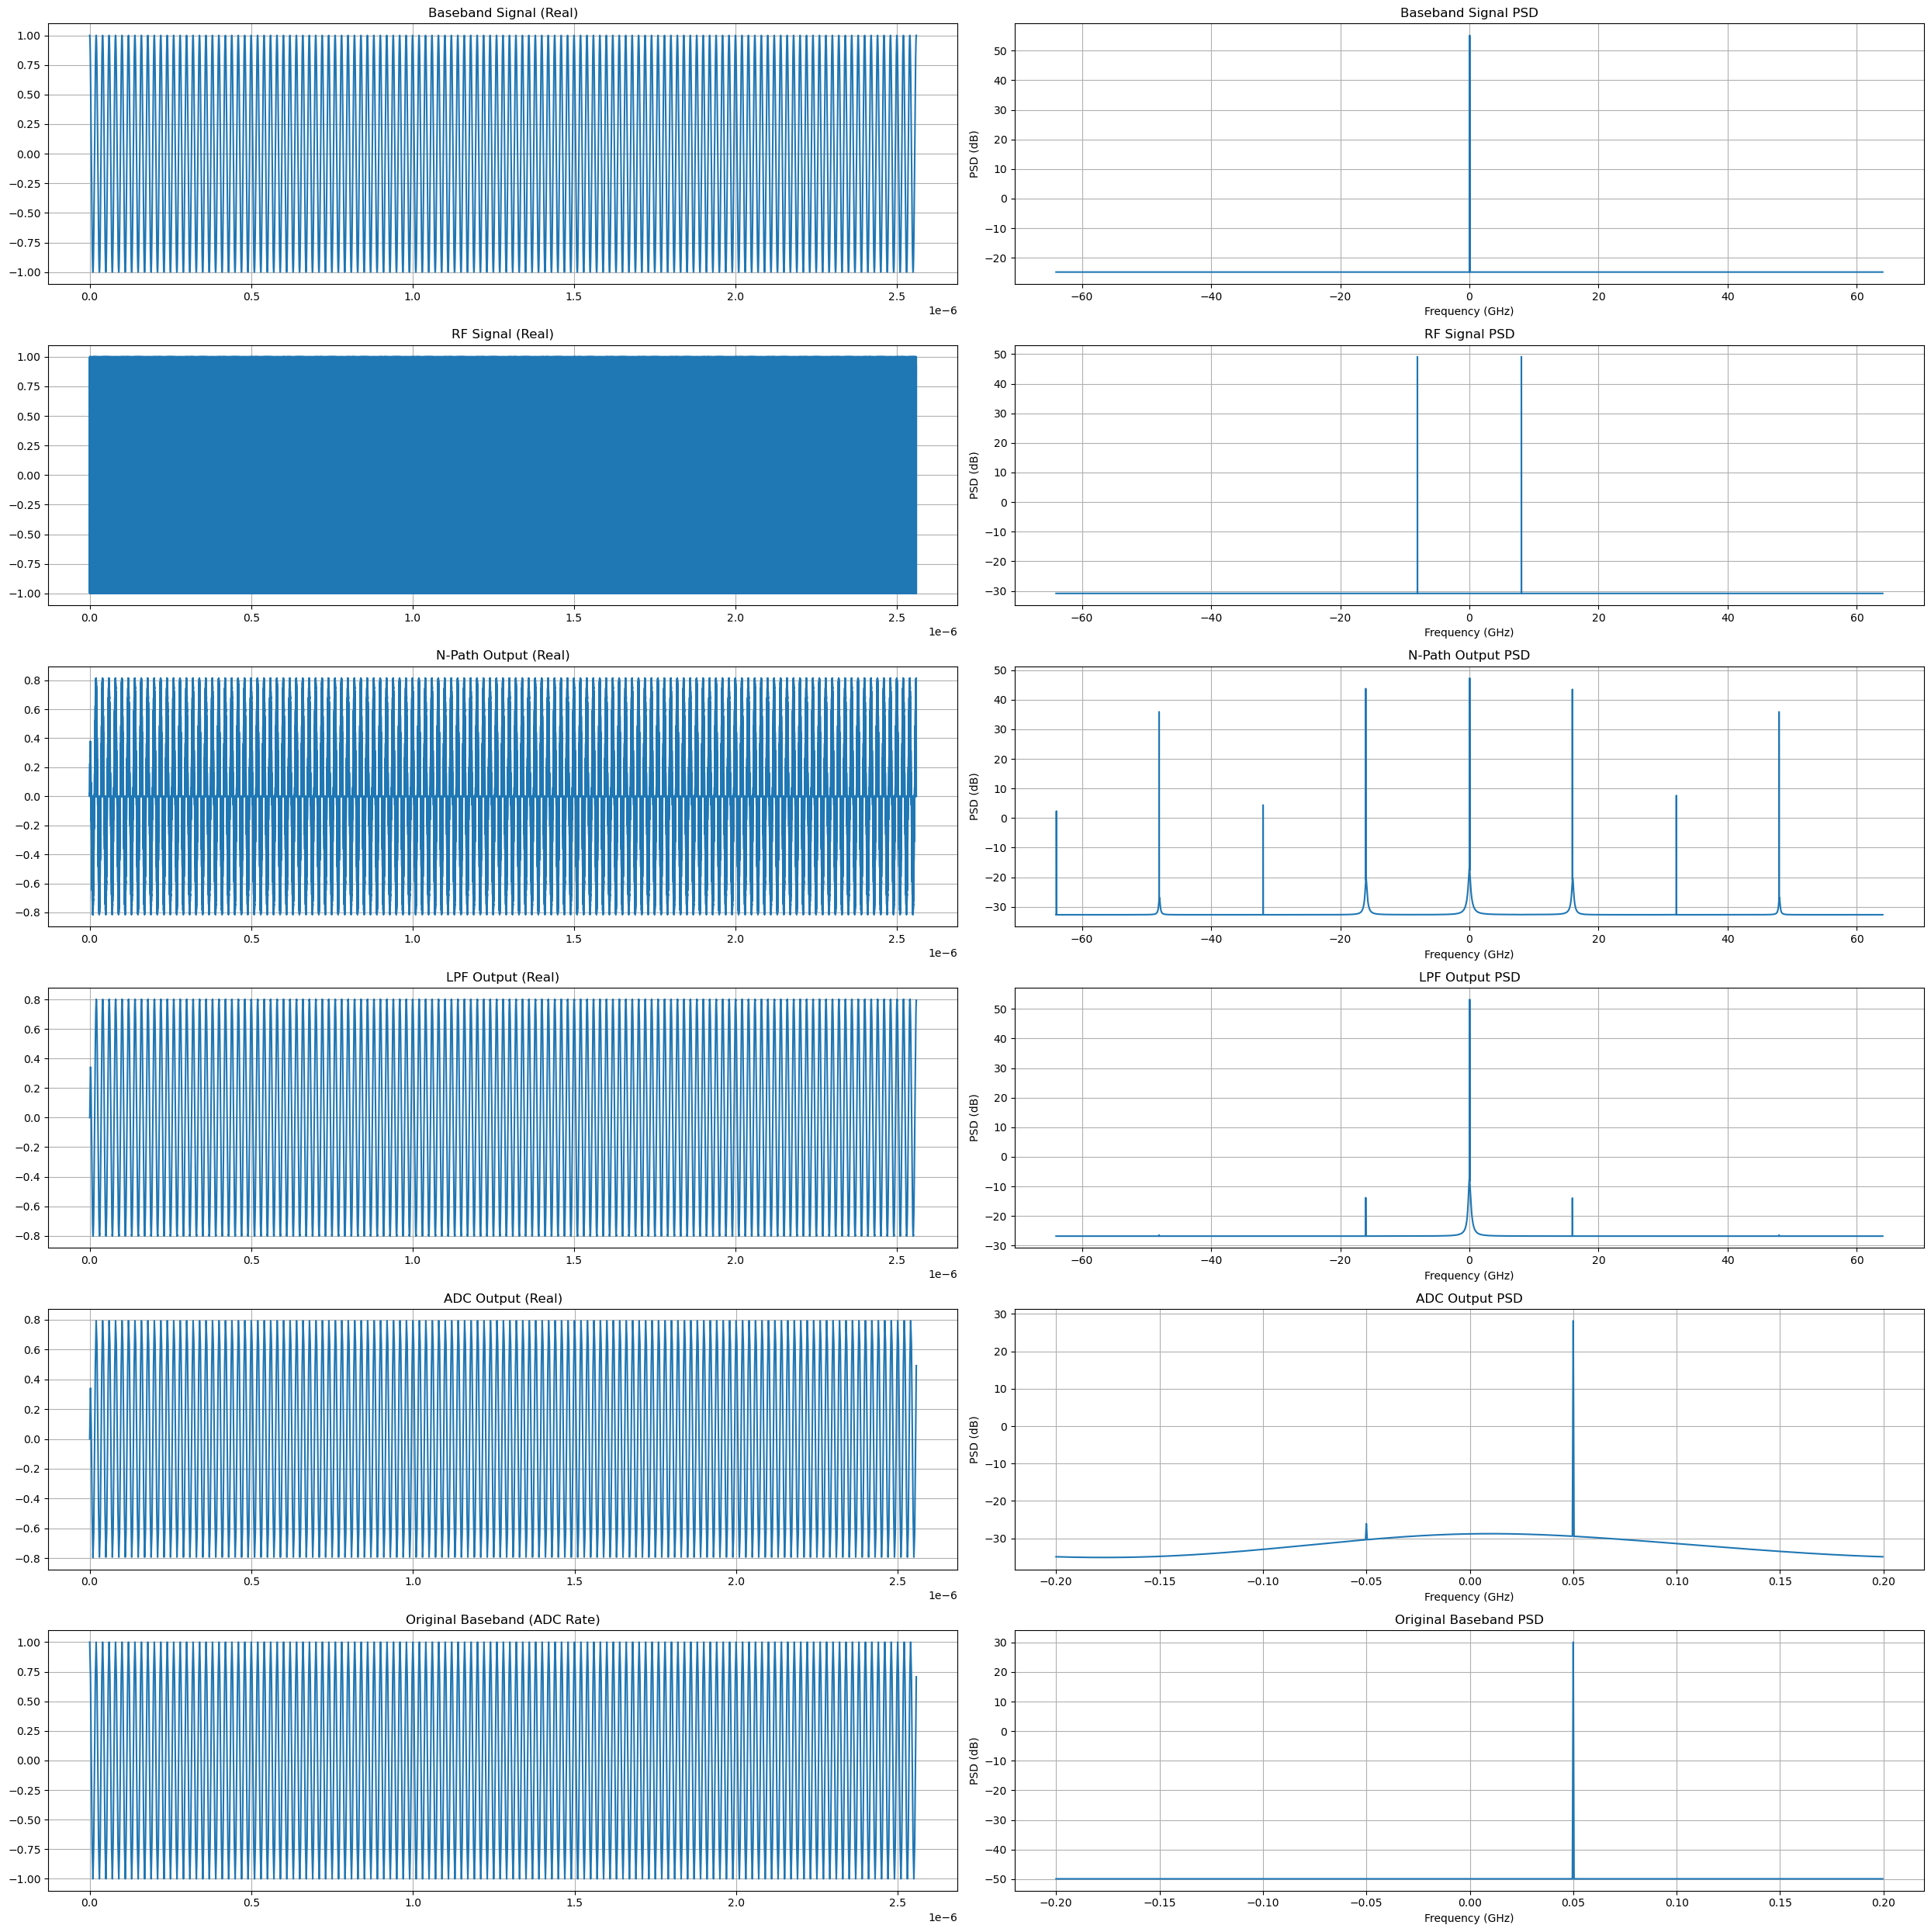

In [2]:
# ==============================
# SYSTEM PARAMETERS
# ==============================

f_b   = 50e6            # Baseband tone frequency (if single-tone is used)
f_p   = 8e9             # Passband carrier frequency
f_lo  = 8e9             # LO frequency for N-path switching
f_adc = 400e6           # ADC sampling rate
N     = 4               # Number of paths in N-path receiver
f_s   = 4 * N * f_lo    # Simulation sampling rate
bw1   = 400e6           # RC bandwidth of N-path filter
bw2   = 400e6           # RC bandwidth after baseband amplifier
bw_ofdm = 100e6         # Total OFDM bandwidth
Nfft    = 512           # Number of subcarriers
T     = 1024 / bw1      # Signal duration
G     = 2               # Baseband amplifier gain

assert f_s % f_adc == 0, "Ensure integer downsampling factor"
assert f_s % (N * f_lo) == 0, "Sampling rate must be an integer multiple of N * f_lo"

# ==============================
# SUB PARAMETERS
# ==============================

R1 = 1                            # N-path RC resistance
R2 = 1                            # Baseband RC resistance
C1 = 1 / (2 * np.pi * R1 * bw1)   # N-path RC capacitor
C2 = 1 / (2 * np.pi * R2 * bw2)   # Baseband RC capacitor

t   = np.arange(0, T, 1/f_s)      # Time vector
adc = int(f_s / f_adc)            # Downsampling factor

# ==============================
# GENERATE COMPLEX BASEBAND SIGNAL
# ==============================

x_b = np.exp(1j * 2*np.pi*f_b*t)

# ==============================
# UP-CONVERSION TO PASSBAND
# ==============================

x_p = np.real(x_b * np.exp(1j * 2*np.pi * f_p * t))
print(f"Total number of input samples: {len(x_p)}")

# ==============================
# N-PATH Receiver (MIXER + LPF)
# ==============================

y_n_path = npath_filter(x_p, N, R1, C1, f_s, f_lo, baseband=True)

# ==============================
# BASEBAND AMPLIFIER + 2nd ORDER LPF
# ==============================

# Apply gain, then cascade two RC filters (2nd order response)
y_out = rc_lpf(G * y_n_path, R=R2, C=C2, f_s=f_s, y_init=0)
y_out = rc_lpf(y_out, R=R2, C=C2, f_s=f_s, y_init=0)

# ==============================
# ADC DOWNSAMPLING
# ==============================

y_adc = y_out[::adc]
t_adc = t[::adc]

# Reference input baseband signal sampled at ADC rate
x_adc = x_b[::adc]

# ==============================
# PLOTS: TIME DOMAIN + PSD
# ==============================

plt.figure(figsize=(25, 25))

# Baseband
plt.subplot(6,2,1)
plt.plot(t, np.real(x_b))
plt.title("Baseband Signal (Real)")
plt.grid(True)

plt.subplot(6,2,2)
plot_psd(x_b, f_s, "Baseband Signal PSD")

# Passband
plt.subplot(6,2,3)
plt.plot(t, np.real(x_p))
plt.title("RF Signal (Real)")
plt.grid(True)

plt.subplot(6,2,4)
plot_psd(x_p, f_s, "RF Signal PSD")

# N-path output
plt.subplot(6,2,5)
plt.plot(t, np.real(y_n_path))
plt.title("N-Path Output (Real)")
plt.grid(True)

plt.subplot(6,2,6)
plot_psd(y_n_path, f_s, "N-Path Output PSD")

# Baseband LPF output
plt.subplot(6,2,7)
plt.plot(t, np.real(y_out))
plt.title("LPF Output (Real)")
plt.grid(True)

plt.subplot(6,2,8)
plot_psd(y_out, f_s, "LPF Output PSD")

# ADC output
plt.subplot(6,2,9)
plt.plot(t_adc, np.real(y_adc))
plt.title("ADC Output (Real)")
plt.grid(True)

plt.subplot(6,2,10)
plot_psd(y_adc, f_adc, "ADC Output PSD")

# Original baseband at ADC rate (reference)
plt.subplot(6,2,11)
plt.plot(t_adc, np.real(x_adc))
plt.title("Original Baseband (ADC Rate)")
plt.grid(True)

plt.subplot(6,2,12)
plot_psd(x_adc, f_adc, "Original Baseband PSD")

plt.tight_layout()
plt.show()

Recovering baseband from stopband

Total number of input samples: 327680


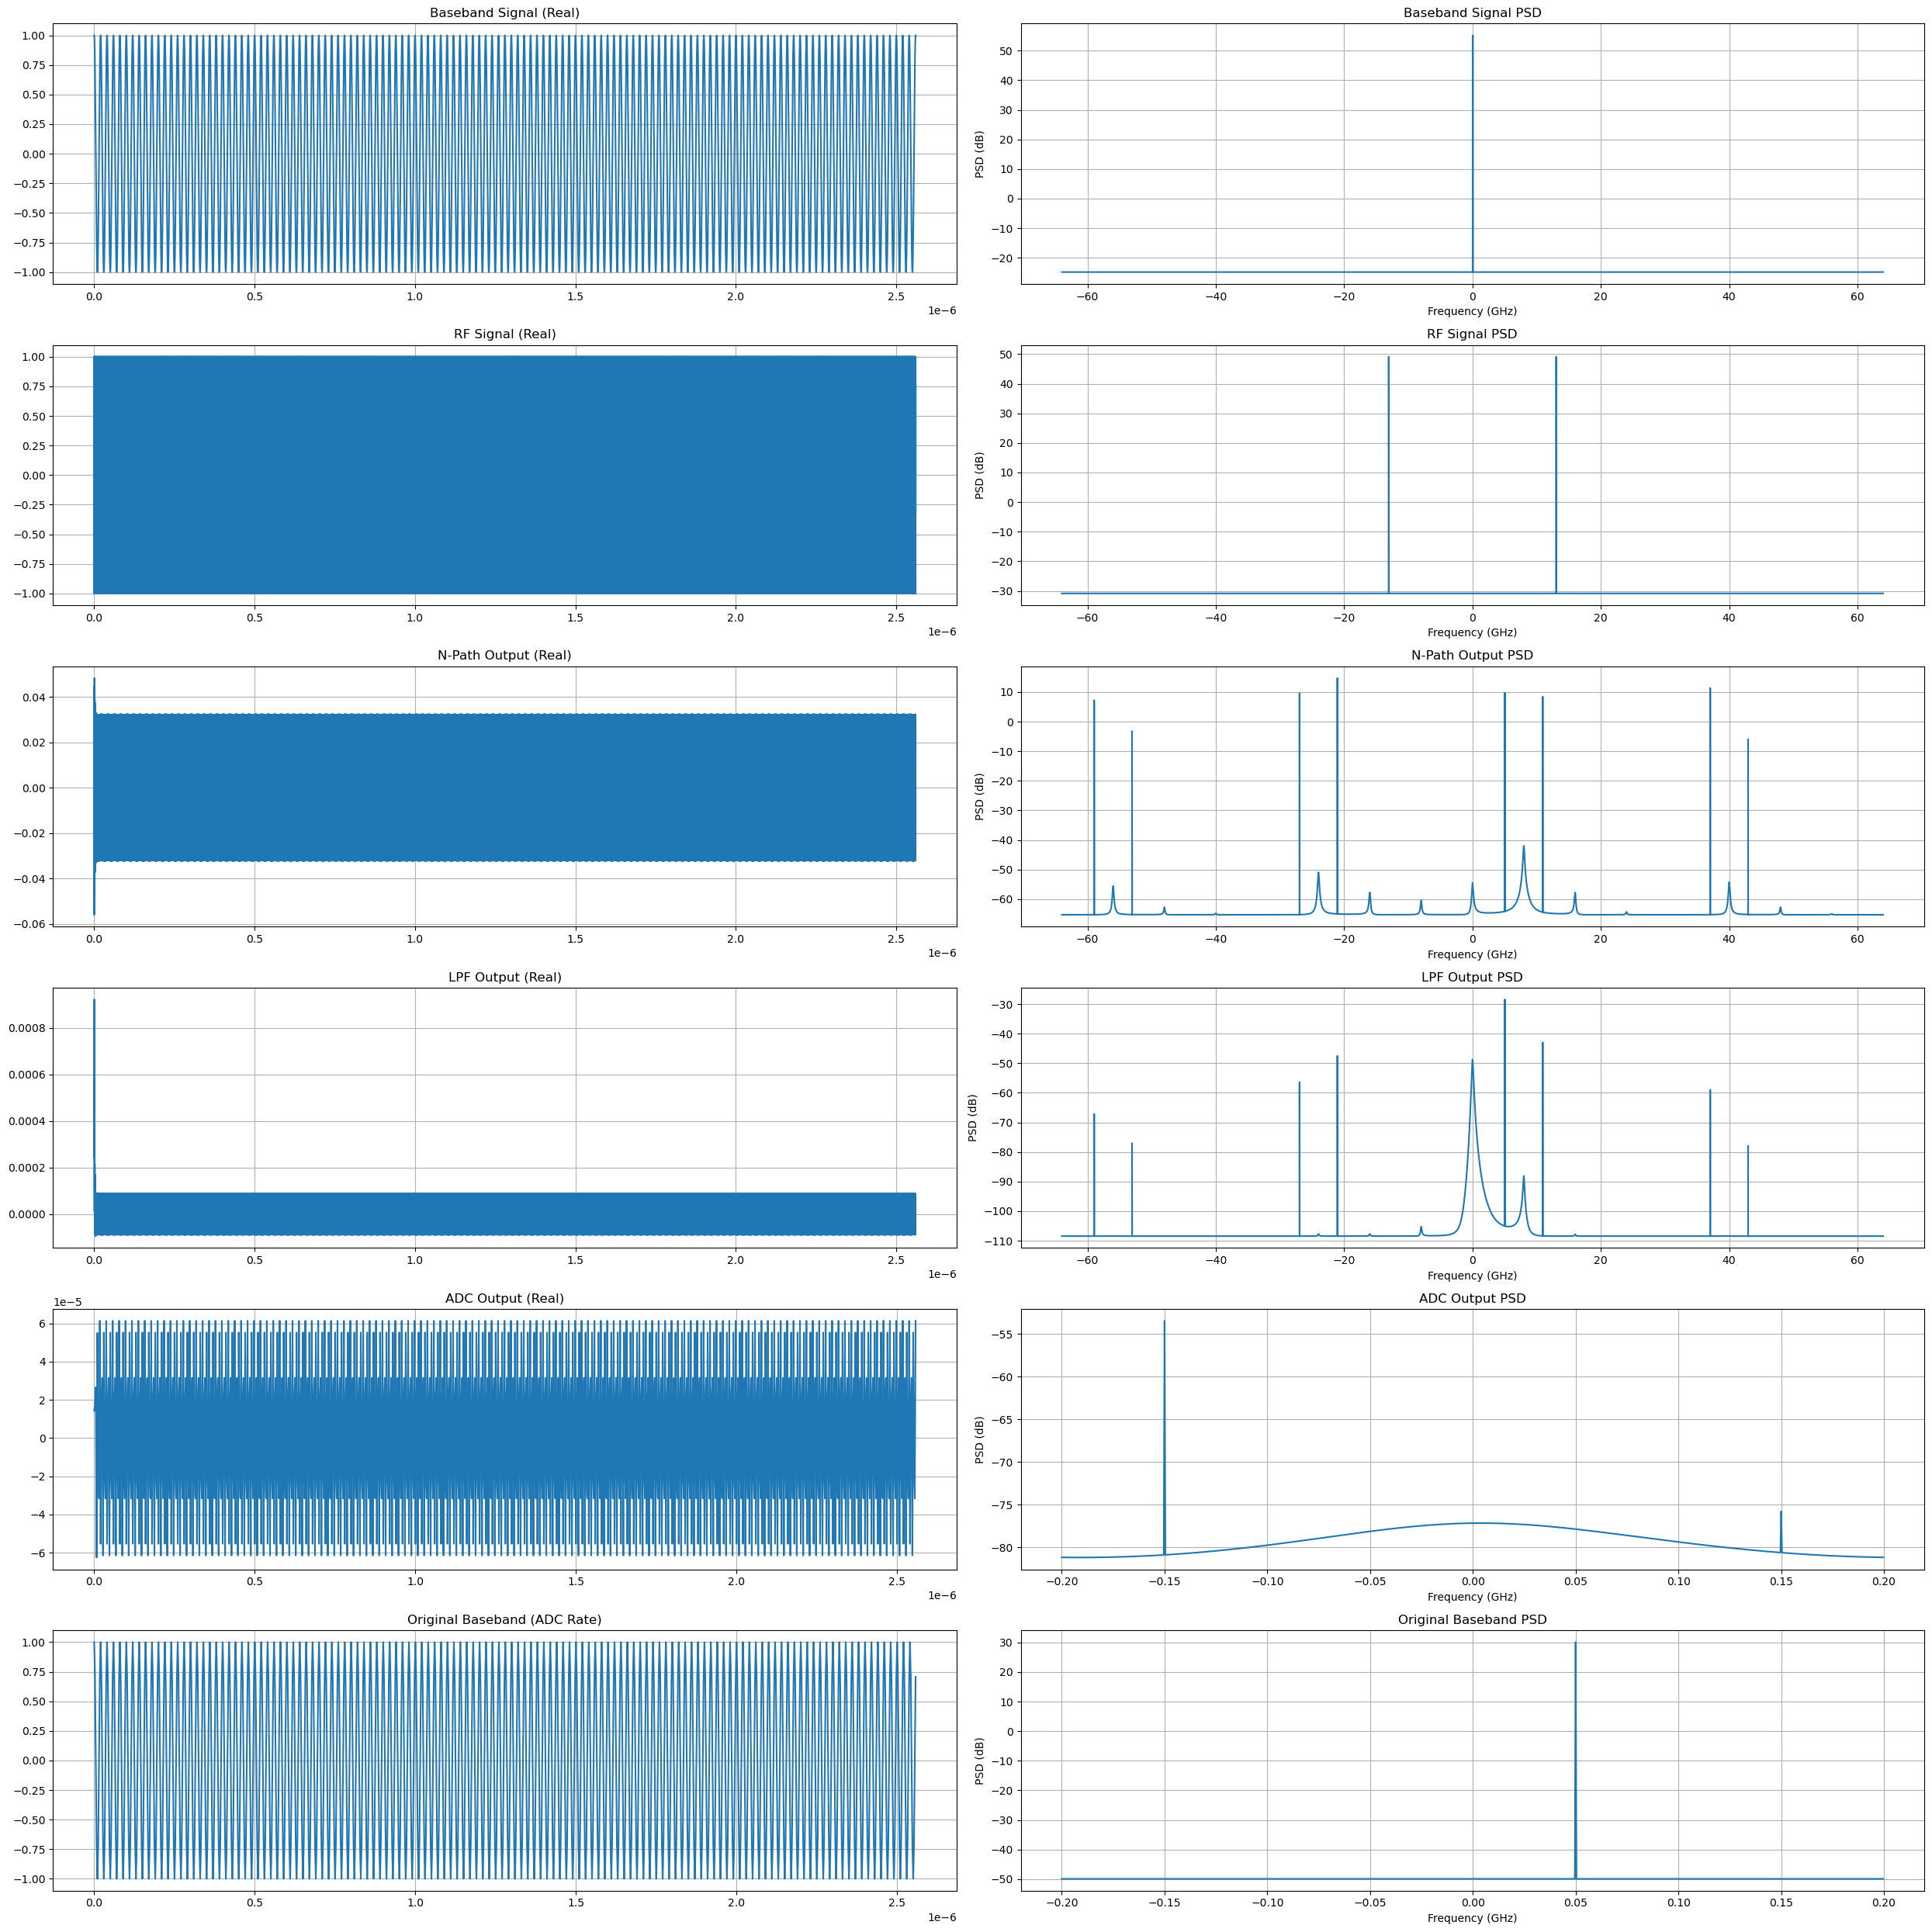

In [3]:
# ==============================
# SYSTEM PARAMETERS
# ==============================

f_b   = 50e6            # Baseband tone frequency (if single-tone is used)
f_p   = 13e9            # Passband carrier frequency
f_lo  = 8e9             # LO frequency for N-path switching
f_adc = 400e6           # ADC sampling rate
N     = 4               # Number of paths in N-path receiver
f_s   = 4 * N * f_lo    # Simulation sampling rate
bw1   = 400e6           # RC bandwidth of N-path filter
bw2   = 400e6           # RC bandwidth after baseband amplifier
bw_ofdm = 100e6         # Total OFDM bandwidth
Nfft    = 512           # Number of subcarriers
T     = 1024 / bw1      # Signal duration
G     = 2               # Baseband amplifier gain

assert f_s % f_adc == 0, "Ensure integer downsampling factor"
assert f_s % (N * f_lo) == 0, "Sampling rate must be an integer multiple of N * f_lo"

# ==============================
# SUB PARAMETERS
# ==============================

R1 = 1                            # N-path RC resistance
R2 = 1                            # Baseband RC resistance
C1 = 1 / (2 * np.pi * R1 * bw1)   # N-path RC capacitor
C2 = 1 / (2 * np.pi * R2 * bw2)   # Baseband RC capacitor

t   = np.arange(0, T, 1/f_s)      # Time vector
adc = int(f_s / f_adc)            # Downsampling factor

# ==============================
# GENERATE COMPLEX BASEBAND SIGNAL
# ==============================

x_b = np.exp(1j * 2*np.pi*f_b*t)

# ==============================
# UP-CONVERSION TO PASSBAND
# ==============================

x_p = np.real(x_b * np.exp(1j * 2*np.pi * f_p * t))
print(f"Total number of input samples: {len(x_p)}")

# ==============================
# N-PATH Receiver (MIXER + LPF)
# ==============================

y_n_path = npath_filter(x_p, N, R1, C1, f_s, f_lo, baseband=True)

# ==============================
# BASEBAND AMPLIFIER + 2nd ORDER LPF
# ==============================

# Apply gain, then cascade two RC filters (2nd order response)
y_out = rc_lpf(G * y_n_path, R=R2, C=C2, f_s=f_s, y_init=0)
y_out = rc_lpf(y_out, R=R2, C=C2, f_s=f_s, y_init=0)

# ==============================
# ADC DOWNSAMPLING
# ==============================

y_adc = y_out[::adc]
t_adc = t[::adc]

# Reference input baseband signal sampled at ADC rate
x_adc = x_b[::adc]

# ==============================
# PLOTS: TIME DOMAIN + PSD
# ==============================

plt.figure(figsize=(25, 25))

# Baseband
plt.subplot(6,2,1)
plt.plot(t, np.real(x_b))
plt.title("Baseband Signal (Real)")
plt.grid(True)

plt.subplot(6,2,2)
plot_psd(x_b, f_s, "Baseband Signal PSD")

# Passband
plt.subplot(6,2,3)
plt.plot(t, np.real(x_p))
plt.title("RF Signal (Real)")
plt.grid(True)

plt.subplot(6,2,4)
plot_psd(x_p, f_s, "RF Signal PSD")

# N-path output
plt.subplot(6,2,5)
plt.plot(t, np.real(y_n_path))
plt.title("N-Path Output (Real)")
plt.grid(True)

plt.subplot(6,2,6)
plot_psd(y_n_path, f_s, "N-Path Output PSD")

# Baseband LPF output
plt.subplot(6,2,7)
plt.plot(t, np.real(y_out))
plt.title("LPF Output (Real)")
plt.grid(True)

plt.subplot(6,2,8)
plot_psd(y_out, f_s, "LPF Output PSD")

# ADC output
plt.subplot(6,2,9)
plt.plot(t_adc, np.real(y_adc))
plt.title("ADC Output (Real)")
plt.grid(True)

plt.subplot(6,2,10)
plot_psd(y_adc, f_adc, "ADC Output PSD")

# Original baseband at ADC rate (reference)
plt.subplot(6,2,11)
plt.plot(t_adc, np.real(x_adc))
plt.title("Original Baseband (ADC Rate)")
plt.grid(True)

plt.subplot(6,2,12)
plot_psd(x_adc, f_adc, "Original Baseband PSD")

plt.tight_layout()
plt.show()

Recovering baseband from passband + stopband

Total number of input samples: 327680


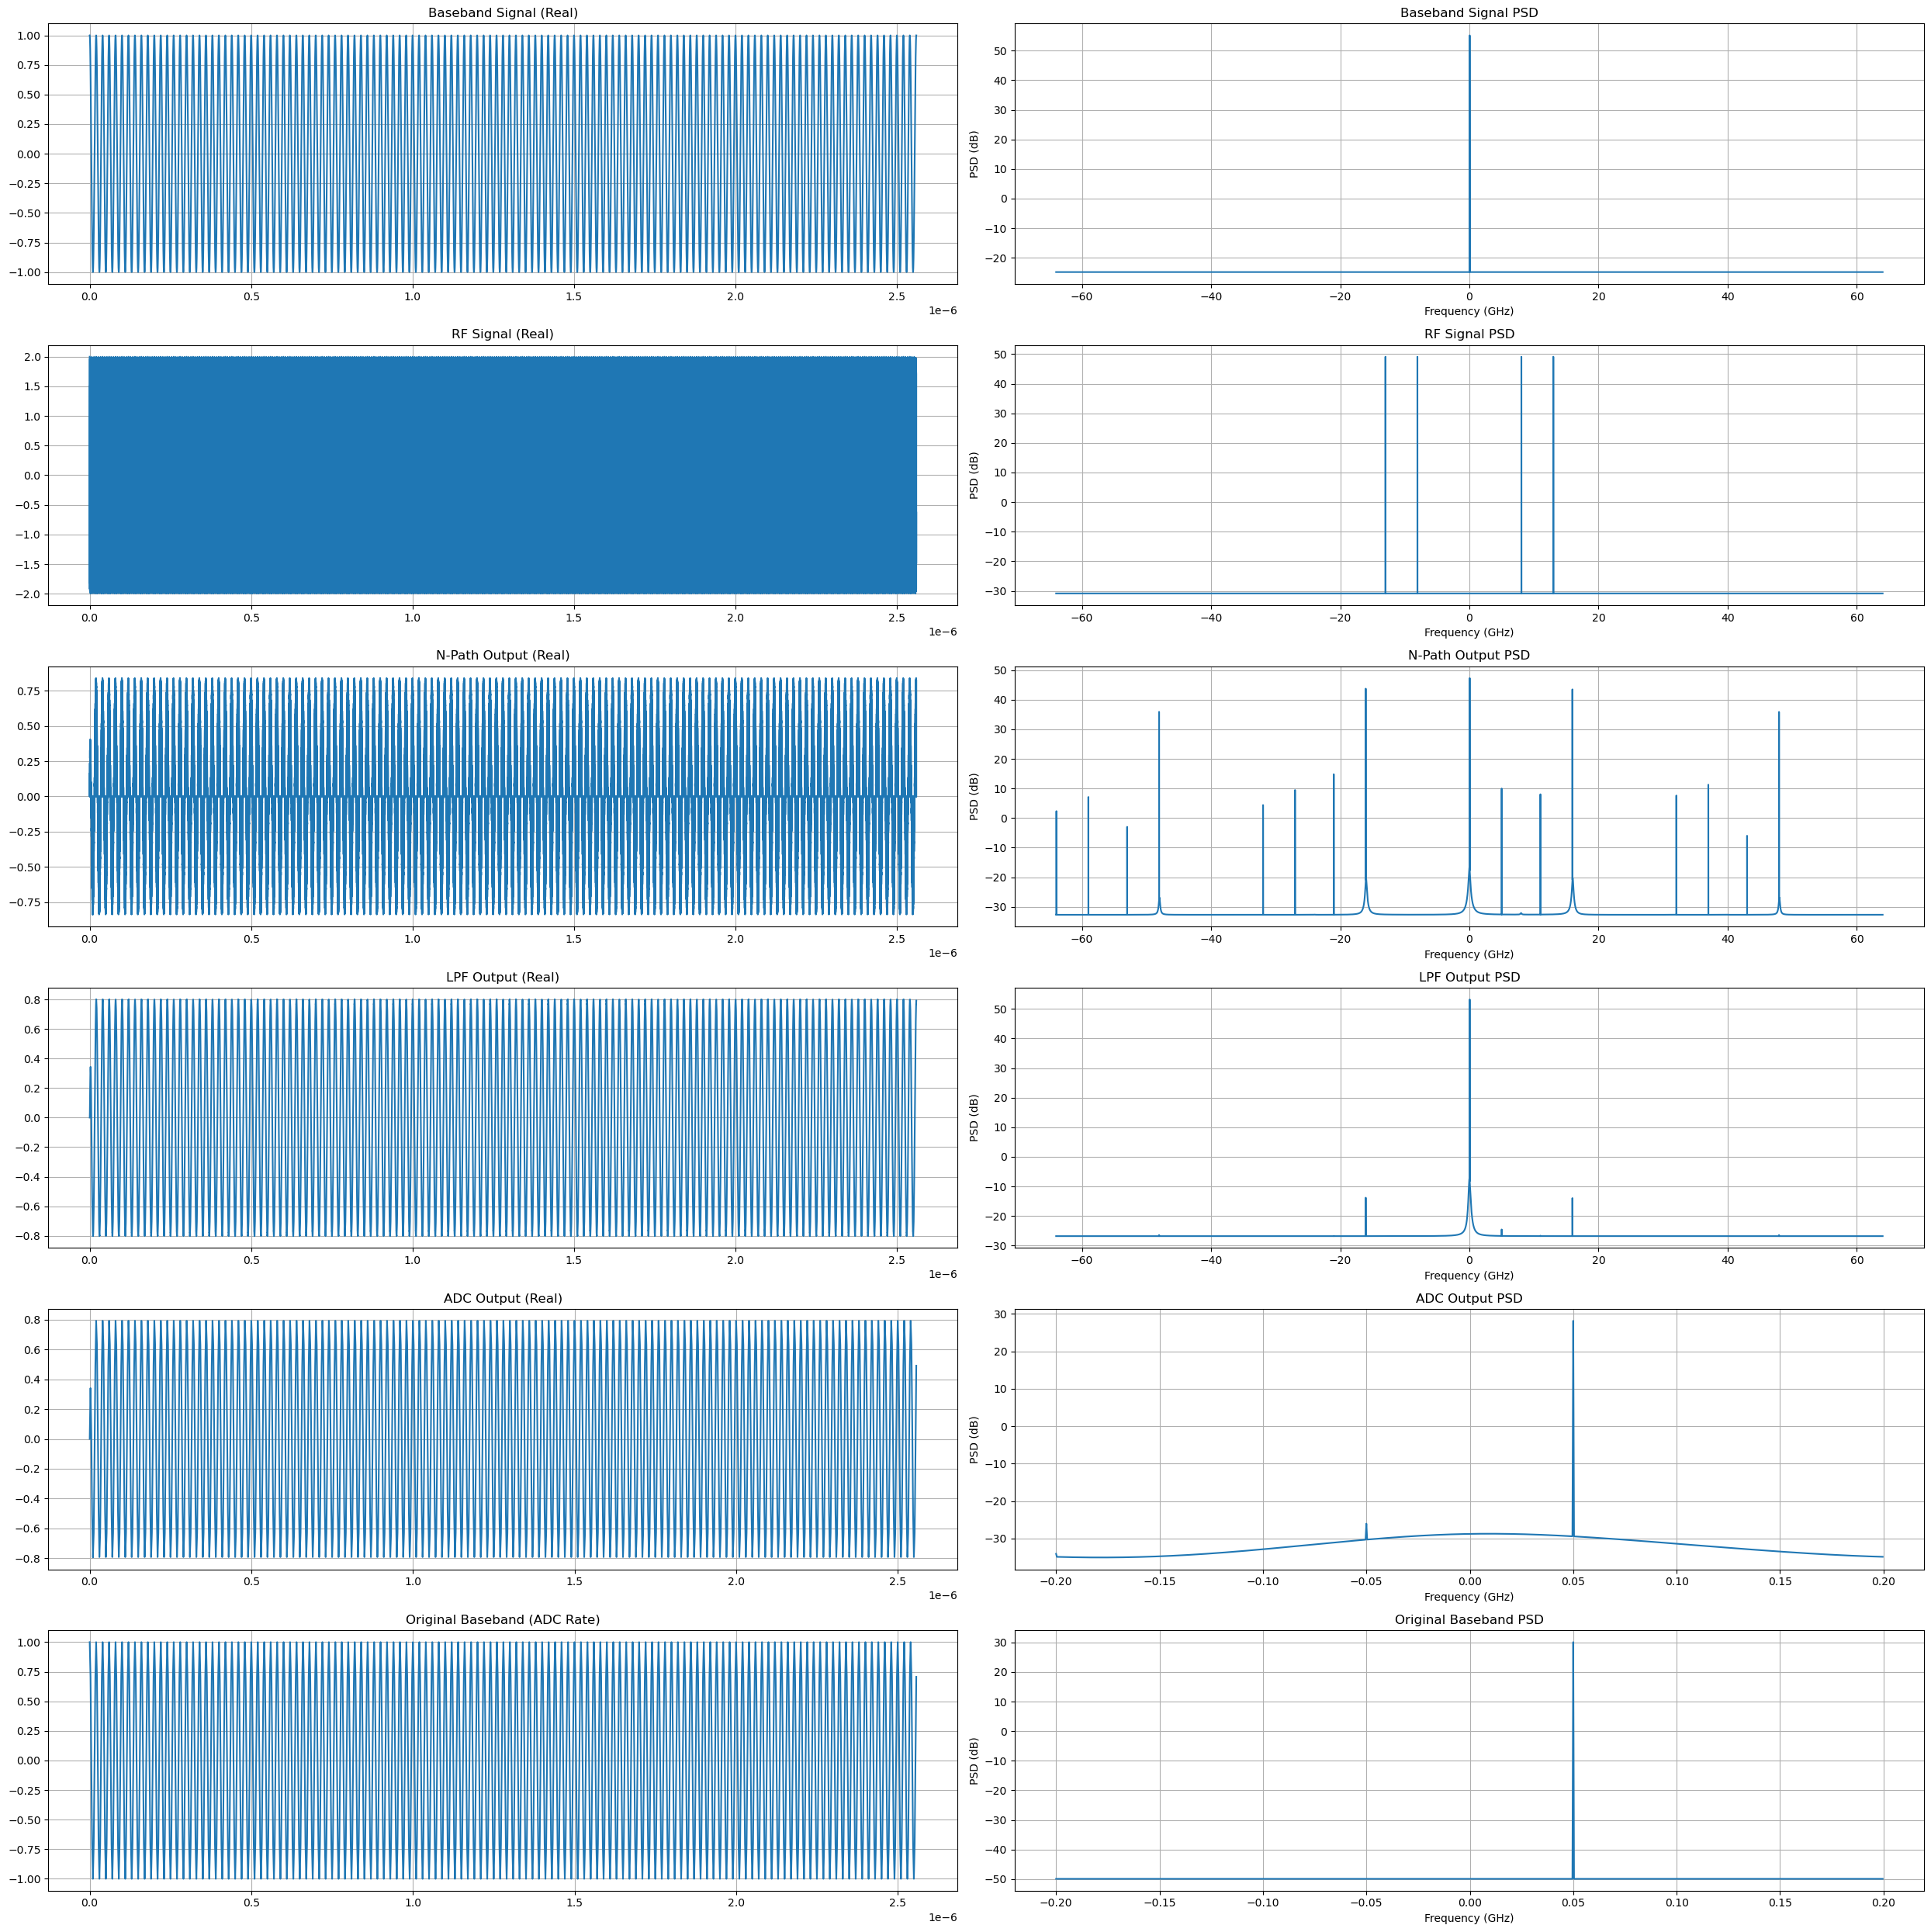

In [4]:
# ==============================
# SYSTEM PARAMETERS
# ==============================

f_b   = 50e6            # Baseband tone frequency (if single-tone is used)
f_p1   = 8e9            # Passband carrier frequency 1
f_p2   = 13e9           # Passband carrier frequency 2
f_lo  = 8e9             # LO frequency for N-path switching
f_adc = 400e6           # ADC sampling rate
N     = 4               # Number of paths in N-path receiver
f_s   = 4 * N * f_lo    # Simulation sampling rate
bw1   = 400e6           # RC bandwidth of N-path filter
bw2   = 400e6           # RC bandwidth after baseband amplifier
bw_ofdm = 100e6         # Total OFDM bandwidth
Nfft    = 512           # Number of subcarriers
T     = 1024 / bw1      # Signal duration
G     = 2               # Baseband amplifier gain

assert f_s % f_adc == 0, "Ensure integer downsampling factor"
assert f_s % (N * f_lo) == 0, "Sampling rate must be an integer multiple of N * f_lo"

# ==============================
# SUB PARAMETERS
# ==============================

R1 = 1                            # N-path RC resistance
R2 = 1                            # Baseband RC resistance
C1 = 1 / (2 * np.pi * R1 * bw1)   # N-path RC capacitor
C2 = 1 / (2 * np.pi * R2 * bw2)   # Baseband RC capacitor

t   = np.arange(0, T, 1/f_s)      # Time vector
adc = int(f_s / f_adc)            # Downsampling factor

# ==============================
# GENERATE COMPLEX BASEBAND SIGNAL
# ==============================

x_b = np.exp(1j * 2*np.pi*f_b*t)

# ==============================
# UP-CONVERSION TO PASSBAND
# ==============================

x_p = np.real(x_b * np.exp(1j * 2*np.pi*f_p1*t) + np.exp(1j * 2*np.pi*f_p2*t))
print(f"Total number of input samples: {len(x_p)}")

# ==============================
# N-PATH Receiver (MIXER + LPF)
# ==============================

y_n_path = npath_filter(x_p, N, R1, C1, f_s, f_lo, baseband=True)

# ==============================
# BASEBAND AMPLIFIER + 2nd ORDER LPF
# ==============================

# Apply gain, then cascade two RC filters (2nd order response)
y_out = rc_lpf(G * y_n_path, R=R2, C=C2, f_s=f_s, y_init=0)
y_out = rc_lpf(y_out, R=R2, C=C2, f_s=f_s, y_init=0)

# ==============================
# ADC DOWNSAMPLING
# ==============================

y_adc = y_out[::adc]
t_adc = t[::adc]

# Reference input baseband signal sampled at ADC rate
x_adc = x_b[::adc]

# ==============================
# PLOTS: TIME DOMAIN + PSD
# ==============================

plt.figure(figsize=(25, 25))

# Baseband
plt.subplot(6,2,1)
plt.plot(t, np.real(x_b))
plt.title("Baseband Signal (Real)")
plt.grid(True)

plt.subplot(6,2,2)
plot_psd(x_b, f_s, "Baseband Signal PSD")

# Passband
plt.subplot(6,2,3)
plt.plot(t, np.real(x_p))
plt.title("RF Signal (Real)")
plt.grid(True)

plt.subplot(6,2,4)
plot_psd(x_p, f_s, "RF Signal PSD")

# N-path output
plt.subplot(6,2,5)
plt.plot(t, np.real(y_n_path))
plt.title("N-Path Output (Real)")
plt.grid(True)

plt.subplot(6,2,6)
plot_psd(y_n_path, f_s, "N-Path Output PSD")

# Baseband LPF output
plt.subplot(6,2,7)
plt.plot(t, np.real(y_out))
plt.title("LPF Output (Real)")
plt.grid(True)

plt.subplot(6,2,8)
plot_psd(y_out, f_s, "LPF Output PSD")

# ADC output
plt.subplot(6,2,9)
plt.plot(t_adc, np.real(y_adc))
plt.title("ADC Output (Real)")
plt.grid(True)

plt.subplot(6,2,10)
plot_psd(y_adc, f_adc, "ADC Output PSD")

# Original baseband at ADC rate (reference)
plt.subplot(6,2,11)
plt.plot(t_adc, np.real(x_adc))
plt.title("Original Baseband (ADC Rate)")
plt.grid(True)

plt.subplot(6,2,12)
plot_psd(x_adc, f_adc, "Original Baseband PSD")

plt.tight_layout()
plt.show()